
## Text Preprocessing

Today we will:
- Clean text
- Convert text to lowercase
- Remove punctuation
- Analyze word frequency
- Visualize common words
- Prepare the dataset for Deep Learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

In [2]:
data = {
    "review": [
        "This product is amazing",
        "I love this product",
        "Very good quality",
        "Excellent product",
        "I am very happy",
        "Amazing quality",
        "This is fantastic",
        "Great product",
        "Very useful and good",
        "I really like it",
        
        "Very bad product",
        "I hate this product",
        "Terrible quality",
        "Very disappointing",
        "I am unhappy",
        "Waste of money",
        "This is horrible",
        "Bad product",
        "Not useful at all",
        "I don't like it"
    ],
    
    "sentiment": [
        "positive"] * 10 + ["negative"] * 10
}

df = pd.DataFrame(data)

df.head()

,review,sentiment
0,This product is amazing,positive
1,I love this product,positive
2,Very good quality,positive
3,Excellent product,positive
4,I am very happy,positive


In [3]:
df["clean_review"] = df["review"].str.lower()

df[["review", "clean_review"]].head()

,review,clean_review
0,This product is amazing,this product is amazing
1,I love this product,i love this product
2,Very good quality,very good quality
3,Excellent product,excellent product
4,I am very happy,i am very happy


In [6]:
df["tokens"] = df["clean_review"].apply(str.split)
df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,this product is amazing,"[this, product, is, amazing]"
1,i love this product,"[i, love, this, product]"
2,very good quality,"[very, good, quality]"
3,excellent product,"[excellent, product]"
4,i am very happy,"[i, am, very, happy]"


In [7]:
all_words = []
for tokens in df["tokens"]:
    all_words.extend(tokens)

word_counts = Counter(all_words)


In [9]:
common_words = word_counts.most_common()

common_words

[('product', 7),
 ('i', 6),
 ('this', 5),
 ('very', 5),
 ('is', 3),
 ('quality', 3),
 ('amazing', 2),
 ('good', 2),
 ('am', 2),
 ('useful', 2),
 ('like', 2),
 ('it', 2),
 ('bad', 2),
 ('love', 1),
 ('excellent', 1),
 ('happy', 1),
 ('fantastic', 1),
 ('great', 1),
 ('and', 1),
 ('really', 1),
 ('hate', 1),
 ('terrible', 1),
 ('disappointing', 1),
 ('unhappy', 1),
 ('waste', 1),
 ('of', 1),
 ('money', 1),
 ('horrible', 1),
 ('not', 1),
 ('at', 1),
 ('all', 1),
 ("don't", 1)]

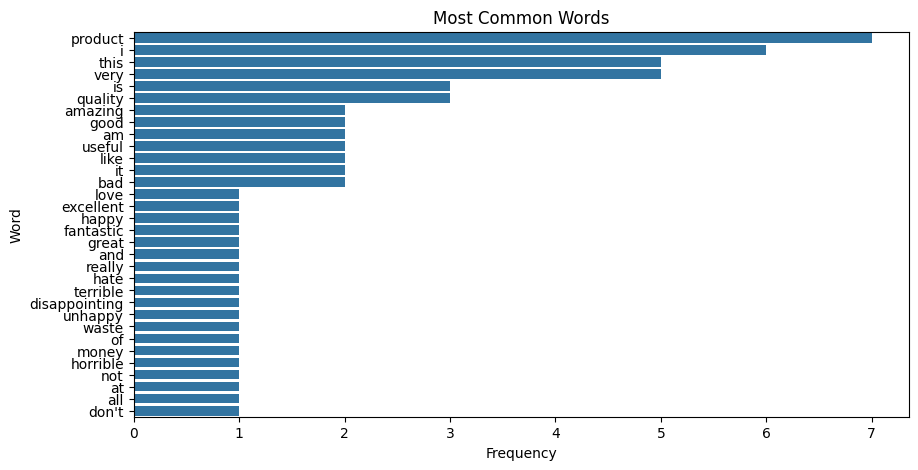

In [10]:
words = [item[0] for item in common_words]
counts = [item[1] for item in common_words]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

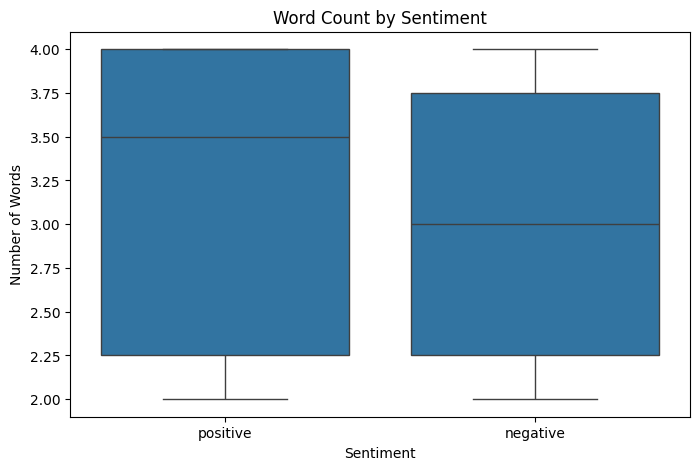

In [11]:
df["word_count"] = df["tokens"].apply(len)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count"
)

plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.show()